# Kayla Hammonds

This code crawls and scrapes Wikipedia pages that contain topics corresponding with the climate change Reddit dataset. Wikipedia text is converted into chunks via sliding window method and then stored in .csv files with their corresponding topics and urls. AI was used to help write code to automate the creation of the .csv files.


In [1]:
import queue
import sys
import csv
import re
from bs4 import BeautifulSoup as bs
import requests
import pandas as pd

In [2]:
# topics related to climate change to explore (based on popular topics from reddit data)

climate_change_topics = [
    "Global Warming",
    "Net-zero emissions", 
    "Intergovernmental Panel on Climate Change",
    "Nitrous Oxide Emissions",
    "Ocean Acidification",
    "Ocean Health Acidification",
    "Paris Agreement",
    "Sea Level Rise",
    "Sea Surface Temperature",
    "Sustainable Energy",
    "Temperature Anomalies",
    "Temperature Rise",
    "Tidal Changes",
    "Urban Flooding",
    "changing weather patterns",
    "climate adaptation",
    "climate education",
    "climate migration",
    "flooding",
    "green economy",
    "greenhouse gas emissions",
    "greenland",
    "Biodiversity Loss",
    "CO2 Emissions",
    "Carbon Dioxide",
    "Carbon Pollution",
    "Carbon footprint",
    "Clean Energy Solutions",
    "Climate Activism",
    "Climate Awareness",
    "Climate Catastrophe",
    "Climate Change",
    "Climate Crisis",
    "Climate Mitigation Measures",
    "Climate-Driven Conflicts",
    "Climate",
    "Coastal Aquifier Salinization",
    "Coastal Erosion",
    "Drought Monitoring",
    "Ecosystem Resilience",
    "Emissions",
    "Environmental Sustainability",
    "Fossil Fuels",
    "Global Climate Change",
    "ocean health",
    "polar ice measurements",
    "renewable energy",
    "saltwater intrusion",
    "sea levels",
    "specific populations",
    "water scarcity",
    "wildfires"
    ]

In [3]:
def make_chunks(paragraphs, window_size=2, stride=1):
    '''
    creates the overlapping paragraphs for sliding window method (adjust window size and stride as needed)
    '''
    chunks = []
    for i in range(0, len(paragraphs) - window_size + 1, stride):
        chunk = " ".join(paragraphs[i:i + window_size])
        chunks.append(chunk)
    return chunks

In [4]:
def is_relevant_text(text):
    '''
    checks if scrapped text is relevant to climate change topics
    '''                 
    text = text.lower()
    return any(topic.lower() in text for topic in climate_change_topics)

In [5]:
def clean_paragraph(text):
    '''
    cleaning the scrapped text

    '''
    text = text.strip()

    # remove in-text citations and references
    text = re.sub(r"\[\s*\d+\s*\]|\[citation needed\]", "", text, flags=re.IGNORECASE)
    text = re.sub(r"\s+", " ", text).strip()
    text = re.sub(r"\s+([,.;:!?])", r"\1", text)
    
    return text

In [6]:
BASE_WIKI_URL = "https://en.wikipedia.org"

# normalize topic names for URL matching
normalized_topics = [topic.lower().replace(" ", "_") for topic in climate_change_topics]

def extract_content(soup):
    ''' 
    extracts all relevant paragraphs and links from soup
    '''

    extracted_paragraphs = []
    extracted_links = set()

    # extract main content
    content = soup.find('div',  class_= 'mw-content-ltr mw-parser-output')

    if content:
        # extract all paragraphs from content
        paragraphs = content.find_all("p")
        # for each paragraph, extract the text, clean it, check if relevant, and add to list of extracted_paragraphs
        for paragraph in paragraphs:
            text = paragraph.get_text(separator=" ", strip=True)
            text = clean_paragraph(text)
            if text and is_relevant_text(text):
                extracted_paragraphs.append(text)
                # extract links from the paragraph
                for link in paragraph.find_all('a', href=True):
                    link_url = link.get('href')
                    # only pull out link if valid
                    if link_url and link_url.startswith("/wiki/"):
                        href_lower = link_url.lower()
                        # normalize link for comparison. if relevant, add to extracted_links
                        if any(topic in href_lower for topic in normalized_topics):
                            extracted_links.add(BASE_WIKI_URL + link_url)

    return extracted_paragraphs, extracted_links

In [7]:
from queue import Queue

urls_to_visit = ["https://en.wikipedia.org/wiki/Climate_change"]
header = { "User-Agent" : "scraping project for class khammonds@uchicago.edu" }
 
starting_url = "https://en.wikipedia.org/wiki/Climate_change"

url_queue = Queue()
url_queue.put(starting_url)
queued = {starting_url} # tracking queue
visited = set()
pages_visited = 0 
results = []

while pages_visited < 100:

    # take the first url
    u = url_queue.get()
    print(f"Processing: {pages_visited}, URL: {u}")
    
    # skip if url has been already processed
    if u in visited:
        continue
    
    # mark this url as processed and update counter to keep track
    visited.add(u)
    pages_visited += 1

    # send request to the url, check if it is a valid url, skip if not
    try:
        r = requests.get(u, headers=header, timeout=5)
        r.raise_for_status()
    except requests.exceptions.RequestException as e:
        print(f"Error with URL {u}: {e}")
        continue

    # parse the url page and extract the text
    soup = bs(r.text, "html.parser")
    paragraphs, links = extract_content(soup)

    # store results
    for paragraph in paragraphs:
        results.append({"url": u, "paragraph": paragraph})
    
    for link in links:
        if link not in visited and link not in queued:
            url_queue.put(link)
            queued.add(link)

# make a list of all paragraphs
all_paragraphs = [result["paragraph"] for result in results]
# make a list of visited URLs
all_urls = [result["url"] for result in results]
# create chunks from all_paragraphs
chunks = make_chunks(all_paragraphs, window_size=2, stride=1)
# remove any empty or very short chunks (<30 words)
chunks = [c for c in chunks if len(c.split()) > 30]
# remove duplicates
chunks = list(set(chunks))



Processing: 0, URL: https://en.wikipedia.org/wiki/Climate_change
Processing: 1, URL: https://en.wikipedia.org/wiki/Greenland_ice_sheet
Processing: 2, URL: https://en.wikipedia.org/wiki/Zero-emissions_vehicle
Processing: 3, URL: https://en.wikipedia.org/wiki/Climate_model
Processing: 4, URL: https://en.wikipedia.org/wiki/Climate_change_and_fisheries
Processing: 5, URL: https://en.wikipedia.org/wiki/Green_Climate_Fund
Processing: 6, URL: https://en.wikipedia.org/wiki/Climate_variability
Processing: 7, URL: https://en.wikipedia.org/wiki/Climate_change_litigation
Processing: 8, URL: https://en.wikipedia.org/wiki/Climate_system
Processing: 9, URL: https://en.wikipedia.org/wiki/Intergovernmental_Panel_on_Climate_Change
Processing: 10, URL: https://en.wikipedia.org/wiki/Global_warming_potential
Processing: 11, URL: https://en.wikipedia.org/wiki/Water_scarcity#Climate_change
Processing: 12, URL: https://en.wikipedia.org/wiki/Renewable_energy_transition
Processing: 13, URL: https://en.wikipedia

In [8]:
# viewing the chunks to ensure they work properly
import textwrap

print("Chunk 0:")
print(textwrap.fill(chunks[0], width=100))

print("Chunk 1:")
print(textwrap.fill(chunks[1], width=100))


Chunk 0:
Due to the COVID-19 pandemic, COP 26 was postponed. In June, the regular SBs were also postponed and
instead the " June Momentum for Climate Change" took place - which was an online event. Building on
its success and coupled with the global lockdowns, COP 26 was also transformed into an online event
only. The meeting was not called a COP, but rather " dialogues ". COP 26 was originally scheduled to
take place from 9 to 19 November 2020, in Glasgow, United Kingdom, but was postponed to 31 October
to 12 November 2021 due to the COVID-19 pandemic. Among other things, this conference led to the
development of the Accelerating to Zero coalition to accelerate the phase-out of fossil fuel
vehicles, and the Glasgow Climate Pact to "phase down" the use of coal-fired power stations.
Chunk 1:
To cut CO 2 emissions intensity by 40–45% below 2005 levels by 2020. To cut greenhouse gas emissions
by 30% (including LULUCF ) below 1990 levels by 2020 if an international agreement is reached
com

In [9]:
# checking number of chunks
len(chunks)

3319

In [ ]:
# Creating .csv files for chunks and corresponding topics/urls (AI used here)
import os
import csv

csv_folder = "wiki_texts"

pairs = list(zip(all_paragraphs, all_urls))

for topic in climate_change_topics:
    print("Creating CSV for topic:", topic)

    filename = topic.replace(" ", "_") + ".csv" # changing topics list to .csv filenames
    path = os.path.join(csv_folder, filename) # add new file to folder

    with open(path, "w", newline="", encoding="utf-8") as f:
        writer = csv.writer(f)
        writer.writerow(["topic", "chunk_id", "chunk_text", "urls"])

        for id, text in enumerate(chunks):
            chunk_urls = []
            for paragraph, url in pairs:
                if paragraph in text and url not in chunk_urls:
                    chunk_urls.append(url)
            urls_str = "; ".join(chunk_urls)
            
            if topic.lower() in text.lower():
                writer.writerow([
                    topic,
                    id,
                    text,
                    urls_str
                ])

    print("Finished:", topic)


Creating CSV for topic: Global Warming
Finished: Global Warming
Creating CSV for topic: Net-zero emissions
Finished: Net-zero emissions
Creating CSV for topic: Intergovernmental Panel on Climate Change
Finished: Intergovernmental Panel on Climate Change
Creating CSV for topic: Nitrous Oxide Emissions
Finished: Nitrous Oxide Emissions
Creating CSV for topic: Ocean Acidification
Finished: Ocean Acidification
Creating CSV for topic: Ocean Health Acidification
Finished: Ocean Health Acidification
Creating CSV for topic: Paris Agreement
Finished: Paris Agreement
Creating CSV for topic: Sea Level Rise
Finished: Sea Level Rise
Creating CSV for topic: Sea Surface Temperature
Finished: Sea Surface Temperature
Creating CSV for topic: Sustainable Energy
Finished: Sustainable Energy
Creating CSV for topic: Temperature Anomalies
Finished: Temperature Anomalies
Creating CSV for topic: Temperature Rise
Finished: Temperature Rise
Creating CSV for topic: Tidal Changes
Finished: Tidal Changes
Creating C

In [ ]:
# checking one file
climate_migration = pd.read_csv("wiki_texts/Climate_Migration.csv")

climate_migration.head(10)

,topic,chunk_id,chunk_text,urls
0,climate migration,190,"In Wales, the village of Fairbourne has been c...",https://en.wikipedia.org/wiki/Climate_migrant
1,climate migration,267,"By bolstering resilience, such projects may re...",https://en.wikipedia.org/wiki/Climate_migrant
2,climate migration,370,Planning for climate migration entails prepari...,https://en.wikipedia.org/wiki/Climate_migrant
3,climate migration,455,Climate change gives rise to migration on a la...,https://en.wikipedia.org/wiki/Climate_migrant
4,climate migration,898,"In 1990, the Intergovernmental Panel on Climat...",https://en.wikipedia.org/wiki/Climate_migrant
5,climate migration,974,The Biden administration in the United States ...,https://en.wikipedia.org/wiki/Climate_migrant
6,climate migration,1218,In an updated report on climate migration rele...,https://en.wikipedia.org/wiki/Climate_migrant
7,climate migration,1380,Few existing international frameworks and regi...,https://en.wikipedia.org/wiki/Climate_migrant
8,climate migration,1438,Several weather events in the 21st century hav...,https://en.wikipedia.org/wiki/Climate_migrant
9,climate migration,1469,The International Organization for Migration e...,https://en.wikipedia.org/wiki/Climate_migrant


In [12]:
# checking chunks added to file correctly
print(textwrap.fill(climate_migration["chunk_text"][0], width=100))

# text looks properly cleaned and formatted

In Wales, the village of Fairbourne has been cited as an area particularly vulnerable to sea level
rise. The local Gwynedd Council has described it as impractical to protect from rising sea levels
and proposed managed retreat. The International Organization for Migration (IOM) expects the scale
of global migration to rise as a result of accelerated climate change. It, therefore, recommends
policymakers around the world to take a proactive stance on the matter. Despite the scale of climate
migration, current legal protections across the world are ineffective in protecting climate
migrants. Few existing international frameworks and regional and domestic legal regimes provide
adequate protection to climate migrants. Typically, climate migrants are not legally recognized as
refugees and therefore do not enjoy international and domestic refugee law protections. In the
Americas, instead of being granted refugee status, individuals displaced by environmental factors
are offered humanitarian v

In [13]:
print(textwrap.fill(climate_migration["chunk_text"][1], width=100))

By bolstering resilience, such projects may reduce the degree of migration people feel compelled to
undertake due to climate-related challenges. Varying levels of investment are made in supporting the
adaptation, resilience, and mobility of neighborhoods, municipalities, and nations in the face of
climate change and consequent environmental migration. This is especially important to consider
since small island states, rural populations, people of color, low-income communities, the elderly,
people with disabilities, coastal urban populations, food and housing insecure households, and
developing countries are especially vulnerable to the worst effects of the climate crisis and
therefore to environmental migration. Just as individuals and countries do not contribute equally to
climate change, they also do not experience the negative effects of the crisis equally. Both short-
and long-term impacts of climate change bring under-prepared communities environmental harm and
exacerbate existing

# Exploratory Data Analysis

In [14]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer

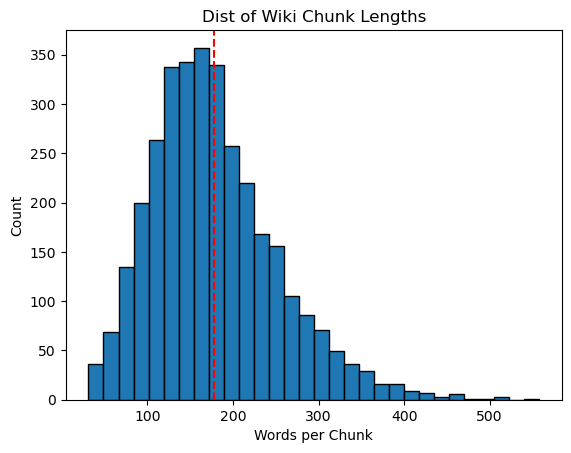

In [30]:
# checking distribution of chunk length

chunk_lens = [len(chunk.split()) for chunk in chunks]
mean_len = np.mean(chunk_lens)

plt.hist(chunk_lens, bins=30, edgecolor="black")
plt.axvline(mean_len, linestyle="--", color="red")
plt.xlabel("Words per Chunk")
plt.ylabel("Count")
plt.title("Dist of Wiki Chunk Lengths")
plt.show()

In [ ]:
# find top n features (code pulled from MACS 30100)

def get_topn_features(X, feature_names, topn=10):
    """
    Inputs:
        X: feature matrix
        feature_names: extracted features during vectorization
        topn: the number of most frequent features to return
    Outputs:
        topn most frequent features and their frequency
    """
    feature_ct = np.asarray(np.sum(X, axis=0)).reshape(-1)

    feature_freq = []

    for i in np.argsort(feature_ct)[::-1][:topn]:
        feature_freq.append({'feature':feature_names[i], 'frequency':feature_ct[i]})

    return pd.DataFrame(feature_freq)

In [17]:
# pulling out the top 20 most frequent words
documents = chunks
vectorizer = CountVectorizer(stop_words="english") # just removing for EDA purposes; will be included in embedding process
X = vectorizer.fit_transform(documents)
feature_names = vectorizer.get_feature_names_out()
top_words_df = get_topn_features(X, feature_names, topn=20)
print(top_words_df)

        feature  frequency
0       climate       8432
1        change       4482
2     emissions       2773
3        global       2302
4        carbon       2263
5       warming       1853
6         water       1801
7           ice       1556
8        energy       1550
9           sea       1348
10        ocean       1347
11    countries       1280
12   greenhouse       1241
13          gas       1156
14     increase       1112
15  temperature       1108
16        level       1024
17      changes       1014
18        years        986
19      dioxide        980


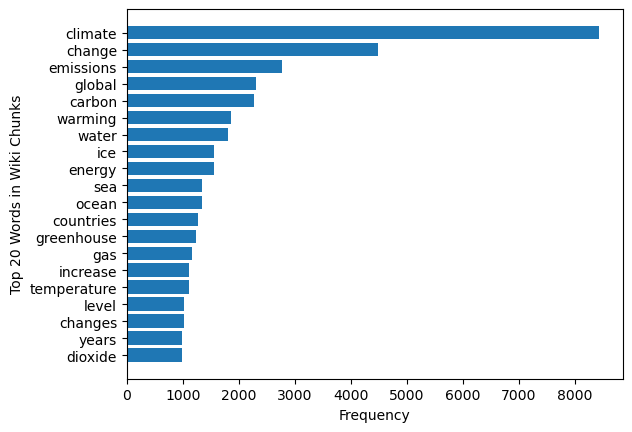

In [18]:
plt.barh(top_words_df["feature"], top_words_df["frequency"])
plt.xlabel("Frequency")
plt.ylabel("Top 20 Words in Wiki Chunks")
plt.gca().invert_yaxis()
plt.show()

Based on the high frequencies of the top words present in the wikipedia chunks, and given the fact that some csv files do not contain any data (i.e. there are some topics that the chunks do not mention at all), we have decided to merge smaller topics into larger related ones in order to still account for their prevalence in the reddit dataset. Ultimately, we believe that there is a lack of data in some of the smaller topics due to the limit of the crawler (100 pages) for the scope of the project. Given the "Top 20 Words in Wiki Chunks" plot, we can use these words to help guide our merging of smaller topics. For example, we can merge topics like CO2_Emissions, Carbon_Footprint, and Carbon_Pollution into one .csv file labelled "Carbon" since this word appears within the top 20. This will be the next step in our plans and then we will start the embedding process for both the Reddit and Wiki text datasets.